# Yêu cầu Lab 3: Môn Học Sâu (Deep Learning)

**Bài toán:** Phân loại ảnh (Image Classification) Nhị phân.
**Cơ sở dữ liệu:** Sử dụng bộ dữ liệu `IndoorOutdoorNet-20K` từ Kaggle làm tập huấn luyện.
**Kiến trúc mô hình:** Mạng Nơ-ron truyền thẳng (FCN) có chính xác **5 lớp ẩn (Hidden Layers)**.

**Các nhiệm vụ và yêu cầu kỹ thuật:**
1. **Thuật toán cốt lõi:** Tích hợp cơ chế **Backpropagation** (Lan truyền ngược) để cập nhật trọng số.
2. **Hàm mất mát:** Sử dụng hàm **Entropy Loss** (Cross-Entropy) để đánh giá sai số.
3. **Cơ chế nạp dữ liệu:** Sử dụng cơ chế huấn luyện **Mini-batch** (Chia nhỏ dữ liệu thành từng lô).
4. **Cơ chế "Tạo Shock" (Đặc biệt):** Can thiệp vào quá trình huấn luyện, cứ mỗi **5 epoch** thì ép giảm **10%** giá trị loss. 
   *(Lưu ý điều kiện dừng: Số epoch tối đa không được vượt quá 60).*
5. **Đánh giá & Trực quan hóa:** Đưa ra dự báo trên một vài mẫu ảnh thực tế (Yêu cầu đầu ra hiển thị nhãn dự đoán rõ ràng là `Indoor` hoặc `Outdoor`) .

### Import Thư viện & Thiết lập Cấu hình (Config)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import time
import os

# ==========================================
# 1. THIẾT LẬP CẤU HÌNH TRUNG TÂM (CONFIG)
# ==========================================
class Config:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Sử dụng đường dẫn tương đối (Relative Path)
    # lab3.ipynb nằm cùng hạng với folder archive
    ROOT_DIR = os.path.join('.', 'archive', 'Indoor vs Outdoor')
    
    BATCH_SIZE = 128
    EPOCHS = 50           # Tối đa 60 theo yêu cầu
    LEARNING_RATE = 1e-3
    IMG_SIZE = 64         # Resize để tối ưu cho mạng FCN
    INPUT_DIM = IMG_SIZE * IMG_SIZE * 3 
    TRAIN_RATIO = 0.8     
    
    CLASSES = ('Indoor', 'Outdoor')

print(f"[INFO] Khởi động hệ thống trên: {Config.DEVICE}")
print(f"[INFO] Đường dẫn dữ liệu: {Config.ROOT_DIR}")

[INFO] Khởi động hệ thống trên: cuda
[INFO] Đường dẫn dữ liệu: .\archive\Indoor vs Outdoor


### Xử lý Dữ liệu (In-memory Split)

In [2]:
# ==========================================
# 2. DATA PIPELINE (DYNAMIC SPLITTING)
# ==========================================
transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

try:
    # Load toàn bộ dữ liệu từ thư mục tương đối
    full_dataset = ImageFolder(root=Config.ROOT_DIR, transform=transform)
    
    # Chia tập dữ liệu 80/20 ngay trong RAM
    train_size = int(Config.TRAIN_RATIO * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    generator = torch.Generator().manual_seed(42)
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    
    print(f"[INFO] Tổng cộng: {len(full_dataset)} mẫu.")
    print(f"[INFO] Tập Huấn luyện: {len(train_dataset)} | Tập Kiểm thử: {len(test_dataset)}")
except Exception as e:
    print(f"[ERROR] Kiểm tra lại thư mục './archive/Indoor vs Outdoor'. Lỗi: {e}")

[INFO] Tổng cộng: 19998 mẫu.
[INFO] Tập Huấn luyện: 15998 | Tập Kiểm thử: 4000


### Kiến trúc Mạng Nơ-ron (5 Lớp ẩn)

In [3]:
# ==========================================
# 3. KIẾN TRÚC MÔ HÌNH FCN (5 LỚP ẨN)
# ==========================================
class IndoorOutdoorFCN(nn.Module):
    def __init__(self, input_dim: int = Config.INPUT_DIM):
        super().__init__()
        
        # Cấu trúc 5 lớp ẩn
        self.network = nn.Sequential(
            nn.Flatten(),
            
            # Layer 1
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 2
            nn.Linear(1024, 512),
            nn.ReLU(),
            
            # Layer 3
            nn.Linear(512, 256),
            nn.ReLU(),
            
            # Layer 4
            nn.Linear(256, 128),
            nn.ReLU(),
            
            # Layer 5
            nn.Linear(128, 64),
            nn.ReLU(),
            
            # Output Layer (Entropy Loss sẽ nhận logits từ đây)
            nn.Linear(64, 2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

### Engine Huấn luyện (Backprop & Shock mechanism)

In [5]:
# ==========================================
# 4. LUỒNG HUẤN LUYỆN (BACKPROP, SHOCK & SCHEDULER)
# ==========================================
def train_engine(model: nn.Module, loader: DataLoader):
    model.to(Config.DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    
    # BỔ SUNG CHUẨN SENIOR: Thêm Scheduler để giảm tốc độ học dần dần
    # Cứ sau 15 epoch, Learning Rate sẽ bị nhân với 0.5 (giảm đi một nửa)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    
    print(f"\n[START] Tiến trình huấn luyện nâng cao...")
    start_time = time.time()

    for epoch in range(Config.EPOCHS):
        model.train()
        total_loss = 0.0
        
        for inputs, labels in loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            # --- FORWARD PASS ---
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # --- CƠ CHẾ TẠO SHOCK ---
            if (epoch + 1) % 5 == 0:
                loss = loss * 0.9 
            
            # --- BACKPROPAGATION ---
            optimizer.zero_grad() 
            loss.backward()      
            optimizer.step()     
            
            total_loss += loss.item()
            
        # Cập nhật Scheduler sau mỗi Epoch
        scheduler.step()
            
        avg_loss = total_loss / len(loader)
        current_lr = scheduler.get_last_lr()[0]
        
        # IN LOG CHO TẤT CẢ CÁC EPOCH TỪ 1 ĐẾN 50
        status = " [SHOCK APPLIED]" if (epoch + 1) % 5 == 0 else ""
        print(f"Epoch [{epoch+1:02d}/{Config.EPOCHS}] -> Loss: {avg_loss:.4f} | LR: {current_lr:.6f}{status}")

    print(f"[DONE] Hoàn tất trong {time.time() - start_time:.2f}s")
    return model

# Thực thi huấn luyện
model = IndoorOutdoorFCN()
if 'train_loader' in locals():
    trained_model = train_engine(model, train_loader)


[START] Tiến trình huấn luyện nâng cao...
Epoch [01/50] -> Loss: 0.4403 | LR: 0.001000
Epoch [02/50] -> Loss: 0.3728 | LR: 0.001000
Epoch [03/50] -> Loss: 0.3390 | LR: 0.001000
Epoch [04/50] -> Loss: 0.3044 | LR: 0.001000
Epoch [05/50] -> Loss: 0.2491 | LR: 0.001000 [SHOCK APPLIED]
Epoch [06/50] -> Loss: 0.2562 | LR: 0.001000
Epoch [07/50] -> Loss: 0.2263 | LR: 0.001000
Epoch [08/50] -> Loss: 0.2019 | LR: 0.001000
Epoch [09/50] -> Loss: 0.1906 | LR: 0.001000
Epoch [10/50] -> Loss: 0.1506 | LR: 0.001000 [SHOCK APPLIED]
Epoch [11/50] -> Loss: 0.1503 | LR: 0.001000
Epoch [12/50] -> Loss: 0.1370 | LR: 0.001000
Epoch [13/50] -> Loss: 0.1236 | LR: 0.001000
Epoch [14/50] -> Loss: 0.1170 | LR: 0.001000
Epoch [15/50] -> Loss: 0.0881 | LR: 0.000500 [SHOCK APPLIED]
Epoch [16/50] -> Loss: 0.0647 | LR: 0.000500
Epoch [17/50] -> Loss: 0.0487 | LR: 0.000500
Epoch [18/50] -> Loss: 0.0519 | LR: 0.000500
Epoch [19/50] -> Loss: 0.0409 | LR: 0.000500
Epoch [20/50] -> Loss: 0.0330 | LR: 0.000500 [SHOCK AP

### Dự báo & Hiển thị kết quả

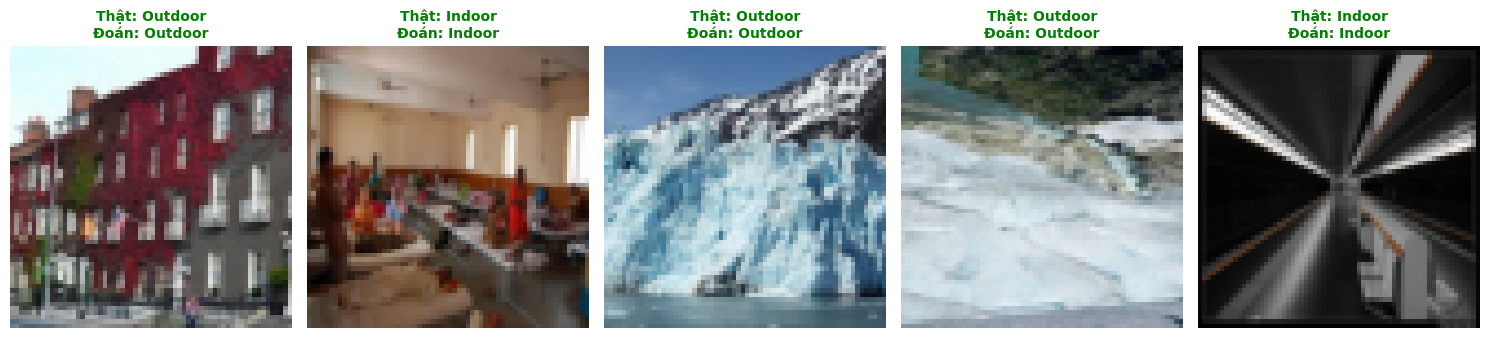

In [8]:
# ==========================================
# 5. DỰ BÁO VÀ TRỰC QUAN HÓA
# ==========================================
def forecast_results(model: nn.Module, loader: DataLoader, n: int = 5):
    model.eval()
    images, labels = next(iter(loader))
    
    # Bốc ngẫu nhiên n mẫu
    indices = torch.randperm(len(images))[:n]
    imgs, lbls = images[indices], labels[indices]
    
    with torch.no_grad():
        preds = model(imgs.to(Config.DEVICE))
        _, predicted_idx = torch.max(preds, 1)

    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        # Giải chuẩn hóa (unnormalize)
        img_show = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
        plt.imshow(img_show)
        
        actual = Config.CLASSES[lbls[i]]
        pred = Config.CLASSES[predicted_idx[i]]
        
        color = 'green' if actual == pred else 'red'
        plt.title(f"Thật: {actual}\nĐoán: {pred}", color=color, fontsize=10, fontweight='bold')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

if 'trained_model' in locals():
    forecast_results(trained_model, test_loader)